
Training Model 1 with config: {'filters': 32, 'lr': 0.001, 'optimizer': 'adam', 'dropout_rate': 0.5}


C:\Users\Ashutosh\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/3
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.7772 - loss: 0.7005 - val_accuracy: 0.9771 - val_loss: 0.0798
Epoch 2/3
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.9650 - loss: 0.1158 - val_accuracy: 0.9818 - val_loss: 0.0589
Epoch 3/3
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.9746 - loss: 0.0827 - val_accuracy: 0.9875 - val_loss: 0.0439
Test Accuracy: 0.9856

Training Model 2 with config: {'filters': 64, 'lr': 0.0005, 'optimizer': 'adam', 'dropout_rate': 0.3}
Epoch 1/3
375/375 ━━━━━━━━━━━━━━━━━━━━ 20s 51ms/step - accuracy: 0.7993 - loss: 0.6696 - val_accuracy: 0.9753 - val_loss: 0.0855
Epoch 2/3
375/375 ━━━━━━━━━━━━━━━━━━━━ 19s 51ms/step - accuracy: 0.9681 - loss: 0.0991 - val_accuracy: 0.9817 - val_loss: 0.0626
Epoch 3/3
375/375 ━━━━━━━━━━━━━━━━━━━━ 21s 55ms/step - accuracy: 0.9799 - loss: 0.0677 - val_accuracy: 0.9872 - val_loss: 0.0452
Test Accuracy: 0.9886

Training Model 3 with config: {'filters': 32, 'lr': 0.01, 'optimizer': 'sgd', 'd

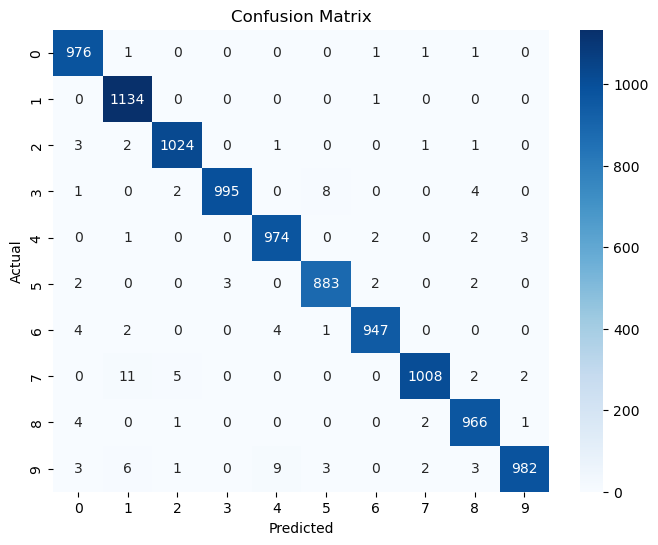


Classification Report:

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       980
           1       0.98      1.00      0.99      1135
           2       0.99      0.99      0.99      1032
           3       1.00      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.98      0.99      1028
           8       0.98      0.99      0.99       974
           9       0.99      0.97      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [2]:
# -----------------------------
# IMPORT LIBRARIES
# -----------------------------
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import confusion_matrix, classification_report

# -----------------------------
# LOAD & PREPROCESS DATA
# -----------------------------
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Reshape (CNN expects 4D input)
X_train = X_train.reshape(-1, 28, 28, 1) / 255.0
X_test = X_test.reshape(-1, 28, 28, 1) / 255.0

# One-hot encoding
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

# -----------------------------
# FUNCTION: BUILD CNN MODEL
# -----------------------------
def build_model(filters=32, kernel_size=(3,3), dropout_rate=0.5, optimizer='adam', lr=0.001):

    model = Sequential()

    # Conv Block 1
    model.add(Conv2D(filters, kernel_size, activation='relu', input_shape=(28,28,1)))
    model.add(MaxPooling2D((2,2)))

    # Conv Block 2
    model.add(Conv2D(filters*2, kernel_size, activation='relu'))
    model.add(MaxPooling2D((2,2)))

    # Flatten
    model.add(Flatten())

    # Dense
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(dropout_rate))

    # Output
    model.add(Dense(10, activation='softmax'))

    # Optimizer selection
    if optimizer == 'adam':
        opt = Adam(learning_rate=lr)
    elif optimizer == 'rmsprop':
        opt = RMSprop(learning_rate=lr)
    else:
        opt = SGD(learning_rate=lr)

    model.compile(optimizer=opt,
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    return model

# -----------------------------
# TRAIN DIFFERENT CONFIGURATIONS
# -----------------------------
configs = [
    {"filters": 32, "lr": 0.001, "optimizer": "adam", "dropout_rate": 0.5},
    {"filters": 64, "lr": 0.0005, "optimizer": "adam", "dropout_rate": 0.3},
    {"filters": 32, "lr": 0.01, "optimizer": "sgd", "dropout_rate": 0.5},
]

results = []

for i, config in enumerate(configs):
    print(f"\nTraining Model {i+1} with config: {config}")

    model = build_model(**config)

    history = model.fit(X_train, y_train_cat,
                        epochs=3,
                        batch_size=128,
                        validation_split=0.2,
                        verbose=1)

    loss, acc = model.evaluate(X_test, y_test_cat, verbose=0)
    print(f"Test Accuracy: {acc:.4f}")

    results.append((config, acc))

# -----------------------------
# BEST MODEL SELECTION
# -----------------------------
best_config, best_acc = max(results, key=lambda x: x[1])
print("\nBest Configuration:", best_config)
print("Best Accuracy:", best_acc)

# Re-train best model for evaluation
best_model = build_model(**best_config)
best_model.fit(X_train, y_train_cat, epochs=5, batch_size=128, validation_split=0.2)

# -----------------------------
# EVALUATION (CONFUSION MATRIX)
# -----------------------------
y_pred = best_model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_classes))